In [1]:
##-RUSHDA QURESHI-2503951-MSBAWE2


In [2]:
# 1. Setup
import pandas as pd

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns

In [6]:
from sklearn.model_selection import train_test_split, cross_val_score

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [8]:
from sklearn.linear_model import LogisticRegression

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

In [10]:
sns.set_style("whitegrid")

In [12]:
# 2. Data Loading
# Adding headers manually as 'iris.data' typically lacks them
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv('iris.data', header=None, names=columns)
print("Dataset Shape:", df.shape)

Dataset Shape: (150, 5)


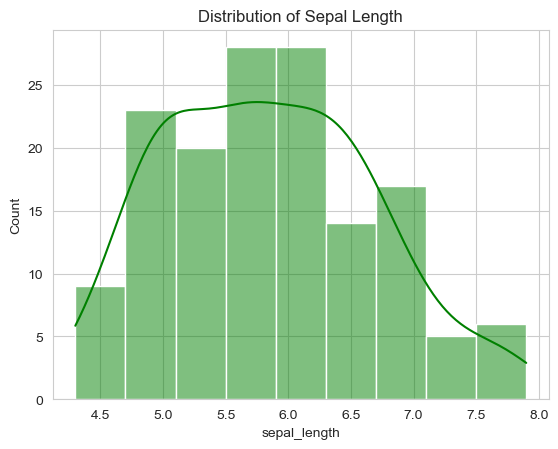

In [13]:
# 3. Exploratory Data Analysis (EDA)
# 4. Univariate analysis: Histogram
sns.histplot(df['sepal_length'], kde=True, color='green')
plt.title('Distribution of Sepal Length')
plt.show()

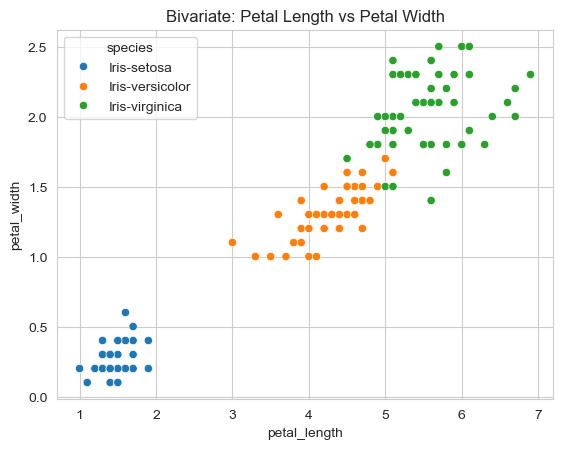

In [14]:
# 5. Bivariate analysis: Scatter plot (Petal vs Sepal)
sns.scatterplot(x='petal_length', y='petal_width', hue='species', data=df)
plt.title('Bivariate: Petal Length vs Petal Width')
plt.show()

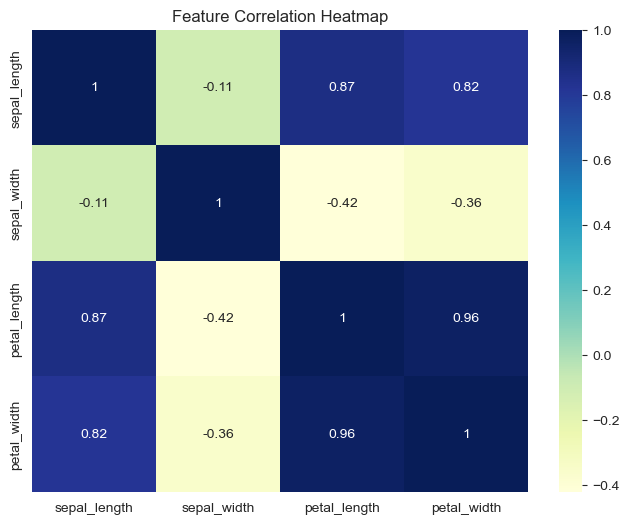

In [15]:
# 6. Correlation matrix and heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='YlGnBu')
plt.title('Feature Correlation Heatmap')
plt.show()

In [16]:
# 7. Class imbalance
print("\nClass Counts:\n", df['species'].value_counts())


Class Counts:
 species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [17]:
# 8. Outlier detection (Z-scores)
z_width = np.abs((df['sepal_width'] - df['sepal_width'].mean()) / df['sepal_width'].std())
print(f"Outliers in Sepal Width (Z > 3): {(z_width > 3).sum()}")

Outliers in Sepal Width (Z > 3): 1


In [18]:
# 10. Feature Engineering
# 12. New Feature: Petal Area (approx)
df['petal_area_approx'] = df['petal_length'] * df['petal_width']

In [19]:
# 13. Encode categorical target
le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])

In [20]:
# --- SAVE CLEANED DATASET ---
df.to_csv('cleaned_iris.csv', index=False)
print("\nCleaned dataset saved as 'cleaned_iris_data.csv'")


Cleaned dataset saved as 'cleaned_iris_data.csv'


In [21]:
# 15. Train/Test Split
X = df.drop(['species', 'species_encoded'], axis=1)
y = df['species_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [22]:
# 14. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
# 18. Cross-validation
log_reg = LogisticRegression(max_iter=1000)
cv_acc = cross_val_score(log_reg, X_train_scaled, y_train, cv=5)
print(f"Logistic Regression CV Accuracy: {cv_acc.mean():.4f}")

Logistic Regression CV Accuracy: 0.9583


In [24]:
# 21. Logistic Regression & Confusion Matrix
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)

print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



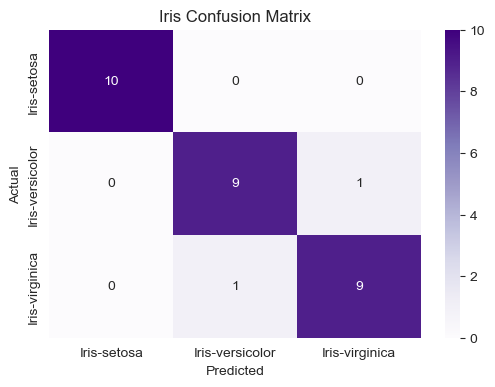

In [25]:
# Visualising results
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Purples', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Iris Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [26]:
# 22. Interpretation: Top influence for first class (Setosa)
importance = pd.DataFrame({'Feature': X.columns, 'Setosa_Coef': log_reg.coef_[0]})
print("\nTop Predictors for Class 'Setosa':\n", importance.sort_values(by='Setosa_Coef', ascending=False))


Top Predictors for Class 'Setosa':
              Feature  Setosa_Coef
1        sepal_width     0.989925
0       sepal_length    -0.909286
4  petal_area_approx    -1.046717
3        petal_width    -1.396721
2       petal_length    -1.500105
